<a href="https://colab.research.google.com/github/DevDharmik/jnj-deutschlandticket-commute-analysis/blob/main/JnJ_Commute_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Workplace + Synthetic Employee Data

We need a home location for J&J and a synthetic employee population (no real data).

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

WORKPLACE = {
    "name": "Johnson & Johnson Medical GmbH",
    "address": "Robert-Koch-Straße 1, 22851 Norderstedt",
    "lat": 53.6975,
    "lon": 9.9800,
}
# Note: in a real project you'd geocode this address via
# geopy.geocoders.Nominatim(...).geocode(address) instead of hardcoding coords.

districts = {
    "Norderstedt":            (53.7010, 9.9750, 0.012),
    "Hamburg-Innenstadt":     (53.5511, 9.9937, 0.015),
    "Langenhorn":             (53.6510, 10.0100, 0.010),
    "Ohlsdorf/Fuhlsbüttel":   (53.6150, 10.0200, 0.012),
    "Alstertal/Poppenbüttel": (53.6430, 10.0700, 0.015),
    "Eidelstedt/Stellingen":  (53.6010, 9.9150, 0.012),
    "Pinneberg":              (53.6626, 9.7998, 0.015),
    "Quickborn":              (53.7333, 9.8967, 0.012),
    "Ahrensburg":             (53.6733, 10.2333, 0.015),
    "Bergedorf":              (53.4897, 10.2159, 0.015),
    "Wandsbek":               (53.5726, 10.0781, 0.015),
    "Kaltenkirchen":          (53.8371, 9.9614, 0.015),
}

N_PER_DISTRICT = 50
rows = []
emp_id = 1
for dname, (clat, clon, spread) in districts.items():
    for _ in range(N_PER_DISTRICT):
        lat = np.random.normal(clat, spread)
        lon = np.random.normal(clon, spread)
        rows.append((emp_id, dname, lat, lon))
        emp_id += 1

employees = pd.DataFrame(rows, columns=["employee_id", "district", "home_lat", "home_lon"])
print(employees.shape)
employees.head()

(600, 4)


,employee_id,district,home_lat,home_lon
0,1,Norderstedt,53.706961,9.973341
1,2,Norderstedt,53.708772,9.993276
2,3,Norderstedt,53.698190,9.972190
3,4,Norderstedt,53.719951,9.984209
4,5,Norderstedt,53.695366,9.981511


Why this design: each district center is a real Hamburg-area neighborhood, and we scatter employees around it with a Gaussian (np.random.normal) so it looks like a real residential spread, not points stacked on one pin. spread controls how tight/loose that scatter is in degrees (~1-1.7km).

Step 2: HVV/AKN Station Network

This is the transit network data — stations near the workplace, with line, speed, and frequency.


In [2]:
stations = pd.DataFrame([
    # name,              lat,      lon,     line,   speed_kmh, headway_min
    ("Norderstedt Mitte", 53.6944, 9.9903, "U1",    32, 6),
    ("Garstedt",          53.6862, 9.9827, "U1",    32, 6),
    ("Ochsenzoll",        53.6699, 9.9993, "U1",    32, 6),
    ("Langenhorn Nord",   53.6591, 10.0089, "U1",   32, 6),
    ("Langenhorn Markt",  53.6461, 10.0122, "U1",   32, 6),
    ("Ohlsdorf",          53.6156, 10.0298, "U1",   32, 6),
    ("Kellinghusenstr.",  53.5768, 9.9895, "U1",    32, 6),
    ("Hauptbahnhof",      53.5528, 10.0067, "U1",   32, 6),
    ("Poppenbüttel",      53.6435, 10.0692, "S1",   45, 10),
    ("Ohlsdorf (S1)",     53.6156, 10.0298, "S1",   45, 10),
    ("Eidelstedt",        53.6053, 9.9105, "AKN",   50, 20),
    ("Quickborn",         53.7333, 9.8967, "AKN",   50, 20),
    ("Kaltenkirchen",     53.8371, 9.9614, "AKN",   50, 20),
], columns=["name", "lat", "lon", "line", "speed_kmh", "headway_min"])

# U1 and AKN both terminate at Norderstedt Mitte -> "direct" access to the workplace hub.
# S1 riders have to transfer onto U1 at Ohlsdorf to continue.
DIRECT_LINES = {"U1", "AKN"}
HUB_NAME = "Norderstedt Mitte"
TRANSFER_PENALTY_MIN = 9   # avg platform change + extra wait

print(stations)

                 name      lat      lon line  speed_kmh  headway_min
0   Norderstedt Mitte  53.6944   9.9903   U1         32            6
1            Garstedt  53.6862   9.9827   U1         32            6
2          Ochsenzoll  53.6699   9.9993   U1         32            6
3     Langenhorn Nord  53.6591  10.0089   U1         32            6
4    Langenhorn Markt  53.6461  10.0122   U1         32            6
5            Ohlsdorf  53.6156  10.0298   U1         32            6
6    Kellinghusenstr.  53.5768   9.9895   U1         32            6
7        Hauptbahnhof  53.5528  10.0067   U1         32            6
8        Poppenbüttel  53.6435  10.0692   S1         45           10
9       Ohlsdorf (S1)  53.6156  10.0298   S1         45           10
10         Eidelstedt  53.6053   9.9105  AKN         50           20
11          Quickborn  53.7333   9.8967  AKN         50           20
12      Kaltenkirchen  53.8371   9.9614  AKN         50           20


Why this design: speed_kmh and headway_min are what let us later calculate ride time and average wait time per line. DIRECT_LINES and TRANSFER_PENALTY_MIN encode the real-world fact that U1/AKN riders go straight to Norderstedt Mitte, while S1 riders need one extra transfer — that distinction will matter a lot for the commute-time formula in the next step.

Step 3: Door-to-Door Commute Time Calculation

This is the core logic: for each employee, find their nearest station, then calculate walk → wait → ride → transfer → last-mile time.

In [3]:
WORK_TO_HUB_KM = None  # will compute below

WALK_SPEED_KMH = 4.5
NETWORK_DETOUR_FACTOR = 1.3   # real track distance vs. straight-line distance
MAX_WALK_KM = 1.5             # beyond this, assume bike/feeder-bus access instead
FEEDER_SPEED_KMH = 15.0


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between two points, in km."""
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))


# distance from every station to the hub (Norderstedt Mitte)
hub_row = stations.loc[stations.name == HUB_NAME].iloc[0]
stations["dist_to_hub_km"] = haversine_km(stations.lat, stations.lon, hub_row.lat, hub_row.lon)

# distance from the workplace itself to the hub (the "last mile" leg)
WORK_TO_HUB_KM = haversine_km(WORKPLACE["lat"], WORKPLACE["lon"], hub_row.lat, hub_row.lon)


def nearest_station(lat, lon):
    d = haversine_km(lat, lon, stations["lat"].values, stations["lon"].values)
    i = d.argmin()
    return stations.iloc[i], d[i]


def first_last_mile(dist_km):
    if dist_km <= MAX_WALK_KM:
        return dist_km / WALK_SPEED_KMH * 60, "walk"
    return dist_km / FEEDER_SPEED_KMH * 60, "feeder"


def commute_time(lat, lon):
    st, dist_km = nearest_station(lat, lon)
    first_mile_min, mode = first_last_mile(dist_km)
    wait_min = st.headway_min / 2  # average wait = half the headway

    st_to_hub_km = st.dist_to_hub_km * NETWORK_DETOUR_FACTOR
    ride_min = st_to_hub_km / st.speed_kmh * 60

    if st.line in DIRECT_LINES:
        transfers, transfer_min = 0, 0
    else:
        transfers, transfer_min = 1, TRANSFER_PENALTY_MIN

    last_mile_min = max((WORK_TO_HUB_KM * NETWORK_DETOUR_FACTOR) / WALK_SPEED_KMH * 60, 3)
    total = first_mile_min + wait_min + ride_min + transfer_min + last_mile_min

    return pd.Series({
        "nearest_station": st["name"],
        "station_line": st.line,
        "station_headway_min": st.headway_min,
        "walk_or_feeder": mode,
        "first_last_mile_km": round(dist_km, 2),
        "transfers": transfers,
        "commute_time_min": round(total, 1),
    })


emp = employees.join(employees.apply(lambda r: commute_time(r.home_lat, r.home_lon), axis=1))

# also estimate a rough driving time, for comparison later
emp["straight_km_to_work"] = haversine_km(emp.home_lat, emp.home_lon, WORKPLACE["lat"], WORKPLACE["lon"])
CAR_SPEED_KMH = 32.0
CAR_DETOUR = 1.25
emp["car_time_min"] = (emp.straight_km_to_work * CAR_DETOUR) / CAR_SPEED_KMH * 60

print(emp[["employee_id", "district", "nearest_station", "transfers", "commute_time_min", "car_time_min"]].head())
print(emp.commute_time_min.describe())

   employee_id     district    nearest_station  transfers  commute_time_min  \
0            1  Norderstedt  Norderstedt Mitte          0              23.3   
1            2  Norderstedt  Norderstedt Mitte          0              22.6   
2            3  Norderstedt  Norderstedt Mitte          0              33.0   
3            4  Norderstedt  Norderstedt Mitte          0              27.7   
4            5  Norderstedt  Norderstedt Mitte          0              24.0   

   car_time_min  
0      2.671031  
1      3.581234  
2      1.218333  
3      5.886825  
4      0.602950  
count    600.000000
mean      60.615167
std       23.555597
min       19.000000
25%       46.000000
50%       55.700000
75%       72.225000
max      125.700000
Name: commute_time_min, dtype: float64


Why this design: haversine_km gives straight-line distance (fast, no API needed); multiplying by NETWORK_DETOUR_FACTOR approximates the fact that real transit lines aren't straight. The car_time_min column is calculated now so we can later score "is transit competitive with driving?"


Step 4: Commute-Time Grouping

Now we bucket everyone into the time bands the assessment asks for: ≤30, 31-45, 46-60, >60 minutes.

commute_bucket
<=30 min      6.0
31-45 min    17.7
46-60 min    36.2
>60 min      40.2
Name: proportion, dtype: float64


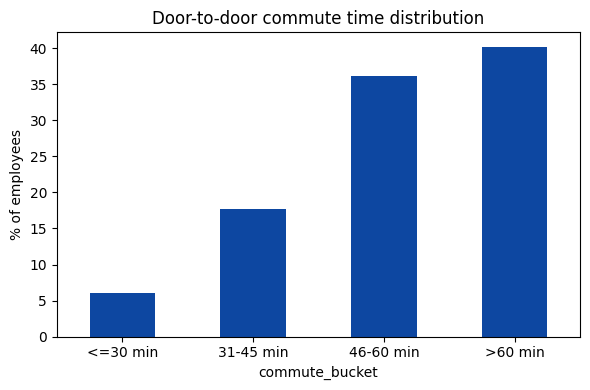

In [4]:
bins = [0, 30, 45, 60, np.inf]
labels = ["<=30 min", "31-45 min", "46-60 min", ">60 min"]
emp["commute_bucket"] = pd.cut(emp.commute_time_min, bins=bins, labels=labels)

bucket_pct = (emp.commute_bucket.value_counts(normalize=True).sort_index() * 100).round(1)
print(bucket_pct)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
bucket_pct.plot(kind="bar", color="#0d47a1", ax=ax)
ax.set_ylabel("% of employees")
ax.set_title("Door-to-door commute time distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Why this design: pd.cut slices the continuous commute_time_min column into the four labeled bands the brief explicitly asks for ("Percentage of employees within 30, 45, 60, and over 60 minutes"). The bar chart gives you a quick visual for the summary section later.

Step 5: Deutschlandticket Adoption Scoring

Now we build a 0-100 score estimating how likely each employee is to adopt the ticket, based on four factors.

adoption_potential
Low       29.0
Medium    68.2
High       2.8
Name: proportion, dtype: float64


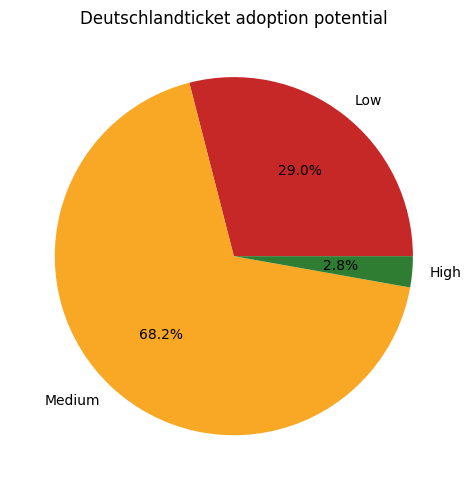

In [5]:
 # a) commute time score: 100 at <=20min, drops to 0 at >=90min
emp["score_time"] = np.clip(100 - (emp.commute_time_min - 20) * (100 / 70), 0, 100)

# b) connectivity score: shorter headway + no transfer = better
headway_score = np.clip(100 - (emp.station_headway_min - 5) * 5, 0, 100)
transfer_score = np.where(emp.transfers == 0, 100, 55)
emp["score_connectivity"] = 0.6 * headway_score + 0.4 * transfer_score

# c) last-mile convenience: closer walk to station = better, feeder access penalised
walk_penalty = np.where(emp.walk_or_feeder == "walk", 0, 20)
emp["score_last_mile"] = np.clip(100 - emp.first_last_mile_km * 30 - walk_penalty, 0, 100)

# d) competitiveness vs. driving: PT roughly as fast as car = strong adoption driver
ratio = emp.commute_time_min / emp.car_time_min.clip(lower=1)
emp["score_competitiveness"] = np.clip(100 - (ratio - 1) * 60, 0, 100)

# combine into one weighted adoption score
emp["adoption_score"] = (
    0.35 * emp.score_time
    + 0.25 * emp.score_connectivity
    + 0.15 * emp.score_last_mile
    + 0.25 * emp.score_competitiveness
).round(1)

emp["adoption_potential"] = pd.cut(
    emp.adoption_score, bins=[-1, 39.999, 69.999, 100], labels=["Low", "Medium", "High"]
)

adoption_pct = (emp.adoption_potential.value_counts(normalize=True).sort_index() * 100).round(1)
print(adoption_pct)

fig, ax = plt.subplots(figsize=(5, 5))
adoption_pct.reindex(["Low", "Medium", "High"]).plot(
    kind="pie", autopct="%.1f%%", colors=["#c62828", "#f9a825", "#2e7d32"], ax=ax, ylabel=""
)
ax.set_title("Deutschlandticket adoption potential")
plt.tight_layout()
plt.show()

Why this design: each sub-score is normalized to 0-100 so the weights (35/25/15/25) are comparable and easy to justify in a write-up — that's the "any metric relevant" part of the brief. The weights themselves are a judgment call; if you want, you can tweak them and see how sensitive the results are — that's actually a good thing to mention in your write-up (shows you understand the model isn't "the one true answer").

Step 6: Final Summary Output

This pulls everything together into the deliverables the brief explicitly asks for: strong/weak areas and key factors.

In [6]:
by_district = emp.groupby("district").agg(
    avg_commute_min=("commute_time_min", "mean"),
    avg_adoption_score=("adoption_score", "mean"),
    transfer_rate=("transfers", "mean"),
    n=("employee_id", "count"),
).round(1).sort_values("avg_adoption_score", ascending=False)

strongest = by_district.head(3)
weakest = by_district.tail(3)

factor_cols = ["commute_time_min", "station_headway_min", "transfers", "first_last_mile_km", "car_time_min"]
key_factors = emp[factor_cols + ["adoption_score"]].corr()["adoption_score"].drop("adoption_score")
key_factors = key_factors.abs().sort_values(ascending=False)

print("=" * 70)
print("SUMMARY — Deutschlandticket adoption potential for J&J Norderstedt")
print("=" * 70)
print(f"\nSynthetic employees modeled: {len(emp)}")

print("\n-- Commute time distribution --")
for lbl, pct in bucket_pct.items():
    print(f"  {lbl:<12} {pct:>5.1f}%")

print("\n-- Estimated Deutschlandticket adoption potential --")
for lbl, pct in adoption_pct.items():
    print(f"  {lbl:<10} {pct:>5.1f}%")

print(f"\n  Overall average adoption score : {emp.adoption_score.mean():.1f} / 100")
print(f"  Employees rated Medium+High    : {(emp.adoption_potential.isin(['Medium','High']).mean()*100):.1f}%")

print("\n-- Areas with strongest PT connectivity --")
print(strongest[["avg_commute_min", "avg_adoption_score", "transfer_rate"]])

print("\n-- Areas with weakest PT connectivity --")
print(weakest[["avg_commute_min", "avg_adoption_score", "transfer_rate"]])

print("\n-- Key factors influencing adoption (|correlation| with adoption_score) --")
print(key_factors)

SUMMARY — Deutschlandticket adoption potential for J&J Norderstedt

Synthetic employees modeled: 600

-- Commute time distribution --
  <=30 min       6.0%
  31-45 min     17.7%
  46-60 min     36.2%
  >60 min       40.2%

-- Estimated Deutschlandticket adoption potential --
  Low         29.0%
  Medium      68.2%
  High         2.8%

  Overall average adoption score : 48.2 / 100
  Employees rated Medium+High    : 71.0%

-- Areas with strongest PT connectivity --
                    avg_commute_min  avg_adoption_score  transfer_rate
district                                                              
Langenhorn                     36.6                63.8            0.0
Norderstedt                    27.8                62.5            0.0
Hamburg-Innenstadt             63.2                59.5            0.0

-- Areas with weakest PT connectivity --
            avg_commute_min  avg_adoption_score  transfer_rate
district                                                      
Bergedorf

Why this design: groupby("district") gives you the "which areas are strong/weak" answer directly from data rather than eyeballing it. The correlation table for key_factors gives you a defensible, data-backed answer to "what drives adoption" instead of just asserting an opinion

Step 7: Interactive Map (Optional deliverable)

First, install folium

In [7]:
!pip install folium -q

In [8]:
import folium
from folium.plugins import MarkerCluster, HeatMap

m = folium.Map(location=[WORKPLACE["lat"], WORKPLACE["lon"]], zoom_start=11, tiles="cartodbpositron")

# workplace marker
folium.Marker(
    [WORKPLACE["lat"], WORKPLACE["lon"]],
    popup=WORKPLACE["name"],
    icon=folium.Icon(color="darkred", icon="briefcase", prefix="fa"),
).add_to(m)

# station markers
for _, s in stations.iterrows():
    folium.CircleMarker(
        [s.lat, s.lon], radius=5, color="black", fill=True, fill_color="black", fill_opacity=0.8,
        popup=f"{s['name']} ({s.line}, every {s.headway_min} min)",
    ).add_to(m)

# employee markers, colored by adoption potential
color_map = {"Low": "#c62828", "Medium": "#f9a825", "High": "#2e7d32"}
cluster = MarkerCluster(name="Employees").add_to(m)
for _, r in emp.iterrows():
    folium.CircleMarker(
        [r.home_lat, r.home_lon], radius=3,
        color=color_map[r.adoption_potential], fill=True,
        fill_color=color_map[r.adoption_potential], fill_opacity=0.7,
        popup=(f"District: {r.district}<br>Commute: {r.commute_time_min} min<br>"
               f"Adoption: {r.adoption_potential} ({r.adoption_score})"),
    ).add_to(cluster)

# adoption-score heatmap layer
heat_data = emp[["home_lat", "home_lon", "adoption_score"]].values.tolist()
HeatMap(heat_data, name="Adoption heatmap", radius=15, show=False).add_to(m)

folium.LayerControl().add_to(m)
m.save("jnj_commute_map.html")
m

Why this design: MarkerCluster keeps 600 dots from cluttering the map at low zoom; HeatMap (toggled off by default via show=False) gives a second view — a density of adoption potential rather than individual points. m.save(...) also writes a standalone HTML file you can open outside Colab or drop straight into your GitHub repo.